The goal of this notebook is to figure out how to calculate the infall times of subhalos onto "massive progenitors" and onto the "main host"
Main goals:
* t_infall_anything_bigger = time or snapshot when the subhalo under scrutiny falls into *any* more massive object (massive progenitor or main host). This would be "first_infall_snap" in the Symphony halo-level data (don't know where exactly yet).
* t_infall_main_host = time when the subhalo under scrutiny falls into *specifically* the main host. This would be "merger_snap" in the Symphony halo-level data, in the "hist" (time-independent) data.
* t_disrupt = time when the subhalo under scrutiny falls below the density required for ROCKSTAR to designate it a subhalo (300 particles)

Using these:
* Create probability density functions (basically histograms) where the infall times are sorted into time bins, allowing us to see if/when the distribution of infall times is peaked and how it behaves across different mass ranges. It would be good to make one version that is not normalized to host formation time, and another that is.
* Create a plot using an autocorrelation function to measure how correlated the infall times of the "massive progenitor" are with the other subhalos (both field and associated I assume? This is the one I'm less clear on). It may also be useful to have a version that shows this effect but for different lines of sight. Autocorrelation should be giving a characteristic time interval for subhalo infalls.
* Calculate the "preprocessed fraction," in other words the number of subhalos that fall onto something else before falling onto the MW, divided by the total number
* Make a plot comparing the location/slope of the SHMF (before and after a particular massive infall), and the other side showing the change in the subhalo count of the massive infalls (GSE, LMC). Would be good to put side-by-side.
* Cross-correlation function (?)

In [1]:
## packages and globals

import symlib
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import sys
import os
from matplotlib import colormaps
import matplotlib.colors as mcolors
from symlib.util import DEFAULT_HALO_NAMES

In [2]:
## GLOBALS
base_dir = "C:/Users/steph/Symphony"
suite_list = ["SymphonyLMC", "SymphonyMilkyWay", "SymphonyGroup", "SymphonyLCluster", "SymphonyCluster"]
colors = ["tab:purple", "tab:blue", "tab:green", "tab:orange", "tab:red"]
alt_colors = ["#6020a8", "#0e5b8f", "#1e8f0a", "#db5f07", "#ad0303"]

#suite_list = ["SymphonyMilkyWay"]
#colors = ["tab:blue"]
#alt_colors = ["#0e5b8f"]

The function "load_infall_data" below is supposed to read in subhalo infall times, sorted into two categories:
1. Infall times corresponding to when subhalos fell into specifically the *main host.* This includes subhalos that fell into a larger subhalo before falling into the main host. This field is read in using hist["merger_snap"]
2. Infall times corresponding to when subhalos fell into *any halo larger than themselves.*

Prior to sorting, subhalos are also filtered using a 300 particle mass cut to reduce noise, and are also checked that they exist at the infall snapshot using the "ok" filter. To check that these cuts are working, the function also spits out how many subhalos were removed by the filter on a per-host and a per-suite basis.

In [3]:
## SUBHALO INFALL DATALOADER FUNCTION:
##
## Key quantities:
##    merger_snap         --> first infall into main host
##    first_infall_snap   --> first infall into ANY halo larger than itself

def load_infall_data(base_dir, suite_list):

    suite_data = {}

    for suite in suite_list:

        print(f"\nLoading suite: {suite}")

        halo_names = DEFAULT_HALO_NAMES[suite]

        ## reading in a global set of scale factors for this suite
        sim_dir0 = symlib.get_host_directory(base_dir, suite, 0)
        scale_factors = symlib.scale_factors(sim_dir0)
        nbins_suite = len(scale_factors)

        ## storing the per-host data
        hosts = []
        
        for halo_index, halo_name in enumerate(halo_names):

            print(f"\nHalo {halo_index + 1}/{len(halo_names)}: {halo_name}", end = "\r", flush = True)

            sim_dir = symlib.get_host_directory(base_dir, suite, halo_name)
            h, hist = symlib.read_subhalos(sim_dir)
            params = symlib.simulation_parameters(sim_dir)

            ## basic quantities: particle mass, virial mass, "ok" array, and "MAIN HOST" & "ANYTHING LARGER" INFALL DATA:
            mp = params["mp"]                                 ## particle mass used for this suite
            
            host_infall_snap = hist["merger_snap"]            ## when subhalos fell into the main host
            first_infall_snap = hist["first_infall_snap"]     ## when subhalos fell into anything more massive than itself

            mvir = h["mvir"]     ## shape (# of subhalos, # of snapshots)
            ok = h["ok"]         ## shape (# of subhalos, # of snapshots)

            
            ## MAIN HOST INFALL:
            ## keep only subhalos which:
            ##   1. have valid infall snapshot (not interested in the main host behavior at the moment)
            ##   2. have infall mass greater than >= 300 particle masses
            ##   3. exist AT the infall snapshot (as determined by Rockstar/Symlib)

            ## INFALL INTO MAIN HOST:
            print(f"\nINFALL INTO MAIN HOST:")

            ## removing the main host (always at snap = 0, biases results)
            host_infall_no_main = host_infall_snap > 0                                       ## removing the main host
            host_infall_rows_no_main = np.where(host_infall_no_main)[0]                      ## subhalo indices, excluding the main host
            host_infall_snaps_no_main = host_infall_snap[host_infall_no_main].astype(int)    ## subhalo infall snapshots, excluding the main host

            ## mass cut, removing subhalos below a 300 particle mass resolution limit
            mass_cut = mvir[host_infall_rows_no_main, host_infall_snaps_no_main] >= 300 * mp
            host_infall_rows_mass_ok = host_infall_rows_no_main[mass_cut]
            host_infall_snaps_mass_ok = host_infall_snaps_no_main[mass_cut]

            ## subhalo survival cut: does the subhalo exist AT the infall snapshot?
            ok_cut = ok[host_infall_rows_mass_ok, host_infall_snaps_mass_ok]
            host_infall_rows_ok = host_infall_rows_mass_ok[ok_cut]
            host_infall_snaps_ok = host_infall_snaps_mass_ok[ok_cut]

            ## INFALL INTO ANYTHING LARGER (conditional on the host):
            first_infall_snaps_sel = first_infall_snap[host_infall_rows_ok].astype(int)

            valid = np.isfinite(host_infall_snaps_ok) & np.isfinite(first_infall_snaps_sel)

            host_infall_snaps_ok = host_infall_snaps_ok[valid]
            host_infall_rows_ok = host_infall_rows_ok[valid]
            first_infall_snaps_sel = first_infall_snaps_sel[valid]

            ## INFALL INTO ANYTHING LARGER (same as above):
            #print(f"\nINFALL INTO ANYTHING LARGER:")
            #print(f"# of subhalos before masking:                     {len(first_infall_snap)}")
            
            #first_infall_no_main = first_infall_snap > 0
            #first_infall_rows_no_main = np.where(first_infall_no_main)[0]
            #first_infall_snaps_no_main = first_infall_snap[first_infall_no_main].astype(int)
            #print(f"# of subhalos, excluding the main host:           {len(first_infall_snaps_no_main)}, {len(first_infall_snap) - len(first_infall_snaps_no_main)} removed")   
            
            #mass_cut = mvir[first_infall_rows_no_main, first_infall_snaps_no_main] >= 300 * mp
            #first_infall_rows_mass_ok = first_infall_rows_no_main[mass_cut]
            #first_infall_snaps_mass_ok = first_infall_snaps_no_main[mass_cut]
            #print(f"# of subhalos, after the 300 particle mass cut:   {len(first_infall_snaps_mass_ok)}, {len(first_infall_snaps_no_main) - len(first_infall_snaps_mass_ok)} removed")

            #ok_cut = ok[first_infall_rows_mass_ok, first_infall_snaps_mass_ok]
            #first_infall_rows_ok = first_infall_rows_mass_ok[ok_cut]
            #first_infall_snaps_ok = first_infall_snaps_mass_ok[ok_cut]
            #print(f"# of subhalos, after the ok survival cut:         {len(first_infall_snaps_ok)}, {len(first_infall_snaps_ok) - len(first_infall_snaps_mass_ok)} removed")
            #print(f"# of subhalos removed:                                 {len(first_infall_snap) - len(first_infall_snaps_ok)} removed")
            
            ## PREPROCESSING FRACTIONS:
            ## of this sample of subhalos that are NOT the main host, are above the 300 particle limit, AND are marked as "ok" by the halo finders,
            ## how many of them fell into something larger before falling into the main host?
            ## a subhalo is "preprocessed" if first_infall_snap < host_infall_snap
            ## we also want to construct time-series data f(t) --> the fraction of subhalos that were preprocessed by time (snapshot) t

            ## evaluating "preprocessed" vs. "not preprocessed"

            ## preprocessing label:
            is_preprocessed = first_infall_snaps_sel < host_infall_snaps_ok

            ## AUTOCORRELATION EVENT ARRAYS

            ## now building the time series information we need for the autocorrelation:
            infall_events = np.zeros(nbins_suite)
            preprocessed_events = np.zeros(nbins_suite)
            
            # valid bin range
            valid_bins = (host_infall_snaps_ok >= 0) & (host_infall_snaps_ok < nbins_suite)

            ## binning & accumulation (vectorized):
            host_bins = host_infall_snaps_ok[valid_bins]
            pre_bins = is_preprocessed[valid_bins].astype(int)

            ## total infall events
            np.add.at(infall_events, host_bins, 1)

            ## subset that are preprocessed
            np.add.at(preprocessed_events, host_bins, pre_bins)

            ## convert to fraction (for diagnostics):
            preprocessing_fraction_t = np.full(nbins_suite, np.nan)
            mask = infall_events > 0
            preprocessing_fraction_t[mask] = preprocessed_events[mask] / infall_events[mask]

            preprocessing_fraction_scalar = np.nanmean(preprocessing_fraction_t)
            
            print(f"\nPREPROCESSING FRACTION:")
            print(f"Mean Preprocessed fraction: {preprocessing_fraction_scalar:.4f}")
            print(f"\n##############################################################################################################################")


            ## NORMALIZATION USING A50:
            host_mvir = mvir[0, :]                      ## getting the host peak mass
            peak_mass = np.max(host_mvir)
            cross = np.where(host_mvir >= 0.5 * peak_mass)[0]     ## finding the snapshot when the host crossed over its 50% peak mass threshold

            ## SAFE NORMALIZATION
            if len(cross) == 0:
                a50 = np.nan
            else:
                a50 = scale_factors[cross[0]]

            if not np.isfinite(a50) or a50 <= 0:

                host_infall_sf = np.full_like(host_infall_snaps_ok, np.nan)
                first_infall_sf = np.full_like(first_infall_snaps_sel, np.nan)

                host_infall_sf_norm = np.full_like(host_infall_snaps_ok, np.nan)
                first_infall_sf_norm = np.full_like(first_infall_snaps_sel, np.nan)

            else:

                host_infall_sf = scale_factors[host_infall_snaps_ok]
                first_infall_sf = scale_factors[first_infall_snaps_sel]

                host_infall_sf_norm = host_infall_sf / a50
                first_infall_sf_norm = first_infall_sf / a50

            
            ## COUNTS: counting up # of subhalos per time bin
            
            host_infall_counts = np.zeros(nbins_suite)
            first_infall_counts = np.zeros(nbins_suite)

            if len(host_infall_snaps_ok) > 0:
                u, c = np.unique(host_infall_snaps_ok, return_counts = True)
                host_infall_counts[u] = c
            
            if len(first_infall_snaps_sel) > 0:
                u, c = np.unique(first_infall_snaps_sel, return_counts = True)
                first_infall_counts[u] = c


            ## STORING HOST DATA
            host_data = {

                "host_infall_snaps_ok": host_infall_snaps_ok,
                "host_infall_rows_ok": host_infall_rows_ok,
                
                "first_infall_snaps_sel": first_infall_snaps_sel,

                "host_infall_sf": host_infall_sf,
                "host_infall_sf_norm": host_infall_sf_norm,
                "first_infall_sf": first_infall_sf,
                "first_infall_sf_norm": first_infall_sf_norm,
                
                "host_infall_counts": host_infall_counts,
                "first_infall_counts": first_infall_counts,

                "is_preprocessed": is_preprocessed,

                "infall_events": infall_events,
                "preprocessed_events": preprocessed_events,

                "preprocessing_fraction": preprocessing_fraction_scalar,
                "preprocessing_fraction_t": preprocessing_fraction_t,

                "host_mass": peak_mass,
                "a50": a50
            }

            hosts.append(host_data)

        ## STORING PER-SUITE DATA
        suite_data[suite] = {"scale_factors": scale_factors, "hosts": hosts}

        print(f"\nSUITE PREPROCESSING SUMMARY")
        
        fractions = [h["preprocessing_fraction"] for h in hosts]
        print(f"Mean per-halo fraction:   {(np.mean(fractions) * 100):.2f}%")
        print(f"Median per-halo fraction: {(np.median(fractions) * 100):.2f}%")

        print(f"\nFinished suite: {suite} ({len(hosts)} halos)")
        print(f"========================================================================================================================")

    return suite_data

In [4]:
## load data once
suite_data = load_infall_data(base_dir, suite_list)


Loading suite: SymphonyLMC

Halo 1/39: Halo032
INFALL INTO MAIN HOST:

PREPROCESSING FRACTION:
Mean Preprocessed fraction: 0.2671

##############################################################################################################################

Halo 2/39: Halo059
INFALL INTO MAIN HOST:

PREPROCESSING FRACTION:
Mean Preprocessed fraction: 0.4396

##############################################################################################################################

Halo 3/39: Halo0662
INFALL INTO MAIN HOST:

PREPROCESSING FRACTION:
Mean Preprocessed fraction: 0.2969

##############################################################################################################################

Halo 4/39: Halo083
INFALL INTO MAIN HOST:

PREPROCESSING FRACTION:
Mean Preprocessed fraction: 0.2054

##############################################################################################################################

Halo 5/39: Halo088
INFALL INTO MAIN HOST:

PRE

Now defining some functions to plot this infall data in various ways:
1. Row 1 is simply a histogram of the subhalo infall data, sorted into snapshot bins. The solid line is for the host infall data, and the dashed line is for the "anything larger" infall data.
2. Row 2 is a PDF of the subhalo infall data (basically Row 1 but normalized so that the total probability = 100%).
3. Row 3 is a CDF of the subhalo infall data (showing the "fraction of the total").
4. Row 4 is Row 2, normalized to the time (snapshot) when the main host accumulated 50% of its peak mass.
5. Row 5 is Row 3, normalized to the time (snapshot) when the main host accumulated 50% of its peak mass.

In [5]:
## functions to plot the raw, un-normalized data

def compute_raw_counts_stats(raw_counts):
    
    mean = np.mean(raw_counts, axis = 0)
    p16_raw = np.percentile(raw_counts, 16, axis = 0)
    p84_raw = np.percentile(raw_counts, 84, axis = 0)

    return mean, p16_raw, p84_raw

def plot_raw_counts(ax, scale_factors, raw_counts, color, fill = False, label = None):

    mean, p16_raw, p84_raw = compute_raw_counts_stats(raw_counts)
    
    ax.plot(scale_factors, mean, color = color, lw = 2)
    
    if fill:
        ax.fill_between(scale_factors, p16_raw, p84_raw, color = color, alpha = 0.25)

#######################################################################################################################

## PDF HELPER FUNCTIONS
def compute_pdf(values, bins):

    values = np.asarray(values)
    values = values[np.isfinite(values)]

    if len(values) == 0:
        return None, None

    hist, edges = np.histogram(values, bins = bins, density = True)

    centers = 0.5 * (edges[:-1] + edges[1:])

    return centers, hist

def compute_pdf_stats_hosts(hosts, key, bins, mask_fn = None):

    pdf_stack = []
    centers = None

    for h in hosts:

        values = np.asarray(h[key])

        if mask_fn is not None:
            mask = mask_fn(h)
            values = values[mask]

        values = values[np.isfinite(values)]

        if len(values) == 0:
            continue

        c, pdf = compute_pdf(values, bins)

        if pdf is None:
            continue

        centers = c
        pdf_stack.append(pdf)

    pdf_stack = np.asarray(pdf_stack)

    if len(pdf_stack) == 0:
        return None, None, None, None

    mean = np.mean(pdf_stack, axis=0)
    p16  = np.percentile(pdf_stack, 16, axis = 0)
    p84  = np.percentile(pdf_stack, 84, axis = 0)

    return centers, mean, p16, p84


def plot_pdf_hosts(ax, hosts, key, bins, color, fill = False, mask_fn = None, label = None):

    centers, mean, p16, p84 = compute_pdf_stats_hosts(hosts, key, bins, mask_fn)

    if mean is None:
        return

    ax.plot(centers, mean, color = color, lw = 2, label = label)

    if fill:
        ax.fill_between(centers, p16, p84, color = color, alpha = 0.25)

#######################################################################################################################

## CDF HELPER FUNCTIONS
def compute_cdf(values, grid):

    values = np.sort(values)
    if len(values) == 0:
        return np.zeros_like(grid)

    cdf = np.arange(1, len(values) + 1) / len(values)
    return np.interp(grid, values, cdf, left = 0, right = 1)


def compute_cdf_stats_hosts(hosts, key, grid, mask_fn = None):

    cdf_stack = []

    for h in hosts:

        values = h[key]

        if mask_fn is not None:
            mask = mask_fn(h)
            values = values[mask]

        values = values[np.isfinite(values)]
        if len(values) == 0:
            continue

        cdf_stack.append(compute_cdf(values, grid))

    cdf_stack = np.array(cdf_stack)

    if len(cdf_stack) == 0:
        return None, None, None

    mean = np.mean(cdf_stack, axis = 0)
    p16  = np.percentile(cdf_stack, 16, axis = 0)
    p84  = np.percentile(cdf_stack, 84, axis = 0)

    return mean, p16, p84

## function to plot the CDFs
def plot_cdf_hosts(ax, hosts, key, grid, color, fill = False, mask_fn = None, label = None):

    mean, p16, p84 = compute_cdf_stats_hosts(hosts, key, grid, mask_fn)

    if mean is None:
        return

    ax.plot(grid, mean, color = color, lw = 2, label = label)
    
    if fill:
        ax.fill_between(grid, p16, p84, color = color, alpha = 0.25)

In [6]:
## FULL INFALL FIGURE
## Solid lines  --> main host infall
## Dashed lines --> first infall into ANY larger halo

def make_infall_figure_full(suite_data, suite_list, colors, fill):

    nrows = 5
    ncols = len(suite_list)

    fig, ax = plt.subplots(nrows = nrows, ncols = ncols, figsize = (6 * ncols, 4 * nrows), constrained_layout = True, squeeze = False)

    ## predefining grids
    a_grid_raw  = np.linspace(0, 1, 100)
    a_grid_norm = np.linspace(0, 3, 100)

    a_bins_raw = np.linspace(0, 1, 40)
    a_bins_norm = np.linspace(0, 3, 40)


    for i, suite in enumerate(suite_list):

        data = suite_data[suite]
        color = colors[i]
        alt_color = alt_colors[i]
        scale_factors = data["scale_factors"]
        hosts = data["hosts"]

        fractions = np.array([h["preprocessing_fraction"] for h in hosts])
        frac_mean = np.mean(fractions)
        frac_median  = np.median(fractions)


        ## gettings raw counts data:
        host_infall_counts = np.array([h["host_infall_counts"] for h in hosts])
        first_infall_counts = np.array([h["first_infall_counts"] for h in hosts])

#######################################################################################################################

        ## ROW 1: RAW COUNTS

        # main-host infall
        plot_raw_counts(ax[0, i], scale_factors, host_infall_counts, color = color, fill = fill)

        # first infall into any host
        plot_raw_counts(ax[0, i], scale_factors, first_infall_counts, color = alt_color, fill = fill)
        ax[0, i].lines[-1].set_linestyle("--")    # making the "into anything bigger" line dashed

#######################################################################################################################

        ## ROW 2: RAW PDF

        ## same format as before: main host infalls as solid lines, then any-host infalls as dashed lines
        plot_pdf_hosts(ax[1, i], hosts, key = "host_infall_sf", bins = a_bins_raw, color = color, fill = fill)
        plot_pdf_hosts(ax[1, i], hosts, key = "first_infall_sf", bins = a_bins_raw, color = alt_color, fill = fill)
        ax[1, i].lines[-1].set_linestyle("--")

#######################################################################################################################

        ## ROW 3: RAW CDF

        ## you get the gist
        plot_cdf_hosts(ax[2, i], hosts, key = "host_infall_sf", grid = a_grid_raw, color = color, fill = fill)
        plot_cdf_hosts(ax[2, i], hosts, key = "first_infall_sf", grid = a_grid_raw, color = alt_color, fill = fill)
        ax[2, i].lines[-1].set_linestyle("--")

#######################################################################################################################

        ## ROW 4: NORMALIZED PDF

        ## PDF now normalized using a50, otherwise format is the same
        plot_pdf_hosts(ax[3, i], hosts, key = "host_infall_sf_norm", bins = a_bins_norm, color = color, fill = fill)
        plot_pdf_hosts(ax[3, i], hosts, key = "first_infall_sf_norm", bins = a_bins_norm, color = alt_color, fill = fill)
        ax[3, i].lines[-1].set_linestyle("--")

#######################################################################################################################

        ## ROW 5: NORMALIZED CDF

        ## same as above but with the CDF now
        plot_cdf_hosts(ax[4, i], hosts, key = "host_infall_sf_norm", grid = a_grid_norm, color = color, fill = fill)
        plot_cdf_hosts(ax[4, i], hosts, key = "first_infall_sf_norm", grid = a_grid_norm, color = alt_color, fill = fill)
        ax[4, i].lines[-1].set_linestyle("--")

#######################################################################################################################

        ## AXIS LIMITS AND LABELS:

        ax[0, i].set_xlim(0, 1)
        ax[1, i].set_xlim(0, 1)
        ax[2, i].set_xlim(0, 1)
        ax[3, i].set_xlim(0, 3)
        ax[4, i].set_xlim(0, 3)

        ax[0, i].set_title(f"{suite}\nPreprocessing Fraction: {(frac_mean * 100):.2f}%", fontsize = 18)

    ## y-axis labels
    ax[0, 0].set_ylabel("Counts per Snapshot", fontsize = 14)
    ax[1, 0].set_ylabel(r"PDF ($a_{\rm infall}$)", fontsize = 14)
    ax[2, 0].set_ylabel(r"CDF ($a_{\rm infall}$)", fontsize = 14)
    ax[3, 0].set_ylabel(r"PDF ($a_{\rm infall}/a_{50}$)", fontsize = 14)
    ax[4, 0].set_ylabel(r"CDF ($a_{\rm infall}/a_{50}$)", fontsize = 14)

    ## x-labels
    for j in range(ncols):

        ax[0, j].set_xlabel(r"Scale Factor $a(t)$", fontsize = 14)
        ax[1, j].set_xlabel(r"Scale Factor $a(t)$", fontsize = 14)
        ax[2, j].set_xlabel(r"Scale Factor $a(t)$", fontsize = 14)
        ax[3, j].set_xlabel(r"$a_{\rm infall}/a_{50}$", fontsize = 14)
        ax[4, j].set_xlabel(r"$a_{\rm infall}/a_{50}$", fontsize = 14)
    

    return fig, ax

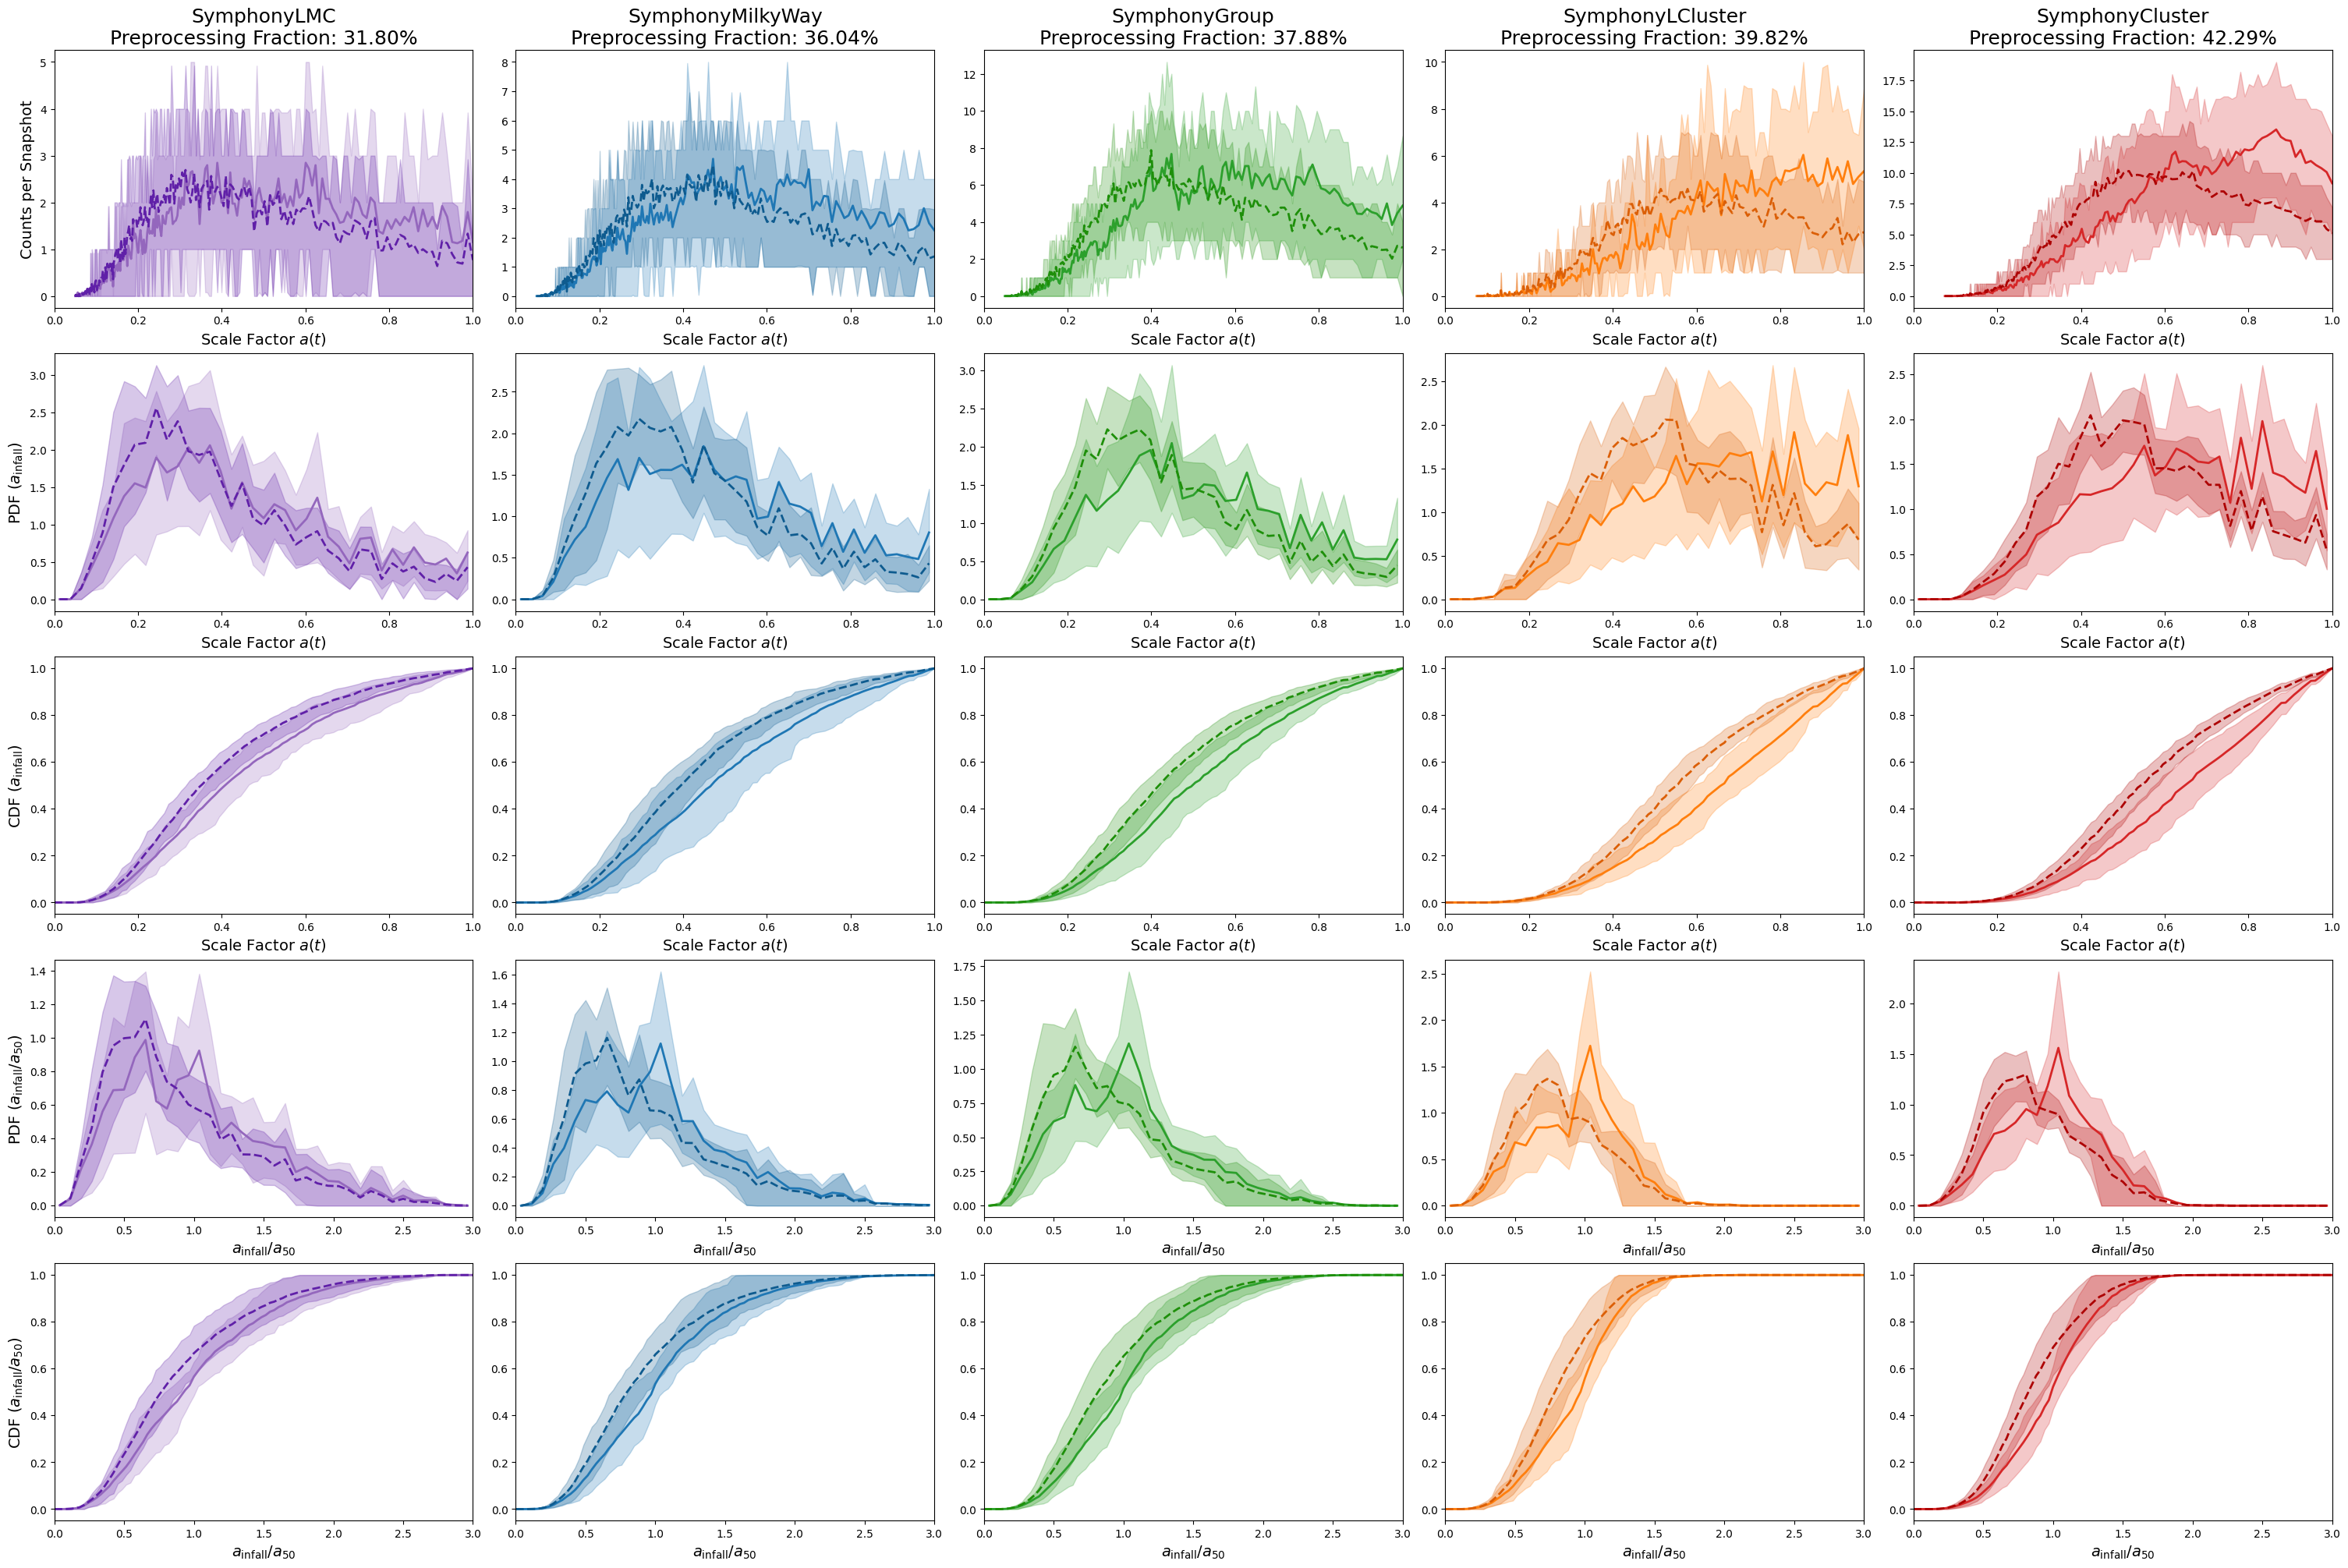

In [7]:
## make plotting adjustments as needed
fig, ax = make_infall_figure_full(suite_data, suite_list, colors, fill = True)

#plt.savefig("ALLCUTS + PREPROCESSING FRACTION.png")
plt.show()

We have plots! Now let's look at the cross-correlation and auto-correlation of infall times, to try to get even more ideas about how the infall times are clustering.
* Auto-correlation would be asking the question "If infall is high at one time, is it also high nearby in time?" This measures temporal clustering/"burstiness" of subhalo infalls. A strong positive autocorrelation corresponds to subhalo infall occurring in bursts, and negative autocorrelations correspond to disturbances or quenching events.
* Cross-correlation would be asking the question "Do peaks in first infall precede/follow peaks in host infall?" This measures whether preprocessing systematically occurs with some kind of time lag/gain. If the correlation peaks in the negative, preprocessing events occur systematically before host infall. If positive, they occur after host infall (unlikely, but worth testing). 

In [12]:
## simple autocorrelation function, no assumptions beyond discrete time bins

def autocorrelation_single(x, max_lag = None, normalize = True):

    x = np.asarray(x, dtype = float)
    T = len(x)

    if max_lag is None:
        max_lag = T - 1

    max_lag = min(max_lag, T - 1)

    ## subtracting the mean
    x = x - np.mean(x)

    ac = np.zeros(max_lag + 1)

    for tau in range(max_lag + 1):
        a = x[:T - tau]
        b = x[tau:]
        ac[tau] = np.mean(a * b)

    if normalize:
        if ac[0] != 0:
            ac = ac / ac[0]

    return ac

## now stacking over halos (no weighting)
def autocorrelation_halo_stack(halo_data_list, field = "infall_events", max_lag = None):

    ac_list = []

    for h in halo_data_list:

        x = h[field]

        ac = autocorrelation_single(x, max_lag=max_lag, normalize=False)
        ac_list.append(ac)

    # align lengths (safety)
    min_len = min(len(a) for a in ac_list)
    ac_list = [a[:min_len] for a in ac_list]

    ac_stack = np.mean(ac_list, axis = 0)

    # normalize stacked result
    if ac_stack[0] != 0:
        ac_stack = ac_stack / ac_stack[0]

    return ac_stack

In [35]:
def make_autocorrelation_figure(suite_data, suite_list, colors, alt_colors, max_lag = 33):

    ncols = len(suite_list)

    fig, ax = plt.subplots(nrows = 1, ncols = ncols, figsize = (6 * ncols, 5), constrained_layout = True, squeeze = False)

    for i, suite in enumerate(suite_list):

        data = suite_data[suite]
        hosts = data["hosts"]

        color = colors[i]
        alt_color = alt_colors[i]

        ## GETTING HALO-STACKED TIME SERIES ARRAYS
        host_series = [h["host_infall_counts"] for h in hosts]
        first_series = [h["first_infall_counts"] for h in hosts]

        ## AUTOCORRELATIONS
        host_ac = autocorrelation_halo_stack(hosts, field = "infall_events", max_lag = max_lag)
        first_ac = autocorrelation_halo_stack(hosts, field = "preprocessed_events", max_lag = max_lag)
        lags = np.arange(len(host_ac))


        ## PLOTTING
        ax[0, i].plot(lags, host_ac, color = color, label = "Main Host Infall Autocorrelation")
        ax[0, i].plot(lags, first_ac, color = alt_color, linestyle = "--", label = "Preprocessed Infall Autocorrelation")

        
        ## FORMATTING
        ax[0, i].set_title(suite, fontsize = 18)
        ax[0, i].set_xlabel("Lag (snapshots)", fontsize = 14)

        if i == 0:
            ax[0, i].set_ylabel("Autocorrelation", fontsize = 14)

        ax[0, i].axhline(0, color = "black", lw = 1, alpha = 0.5)

        ax[0, i].legend(fontsize = 11)

    return fig, ax

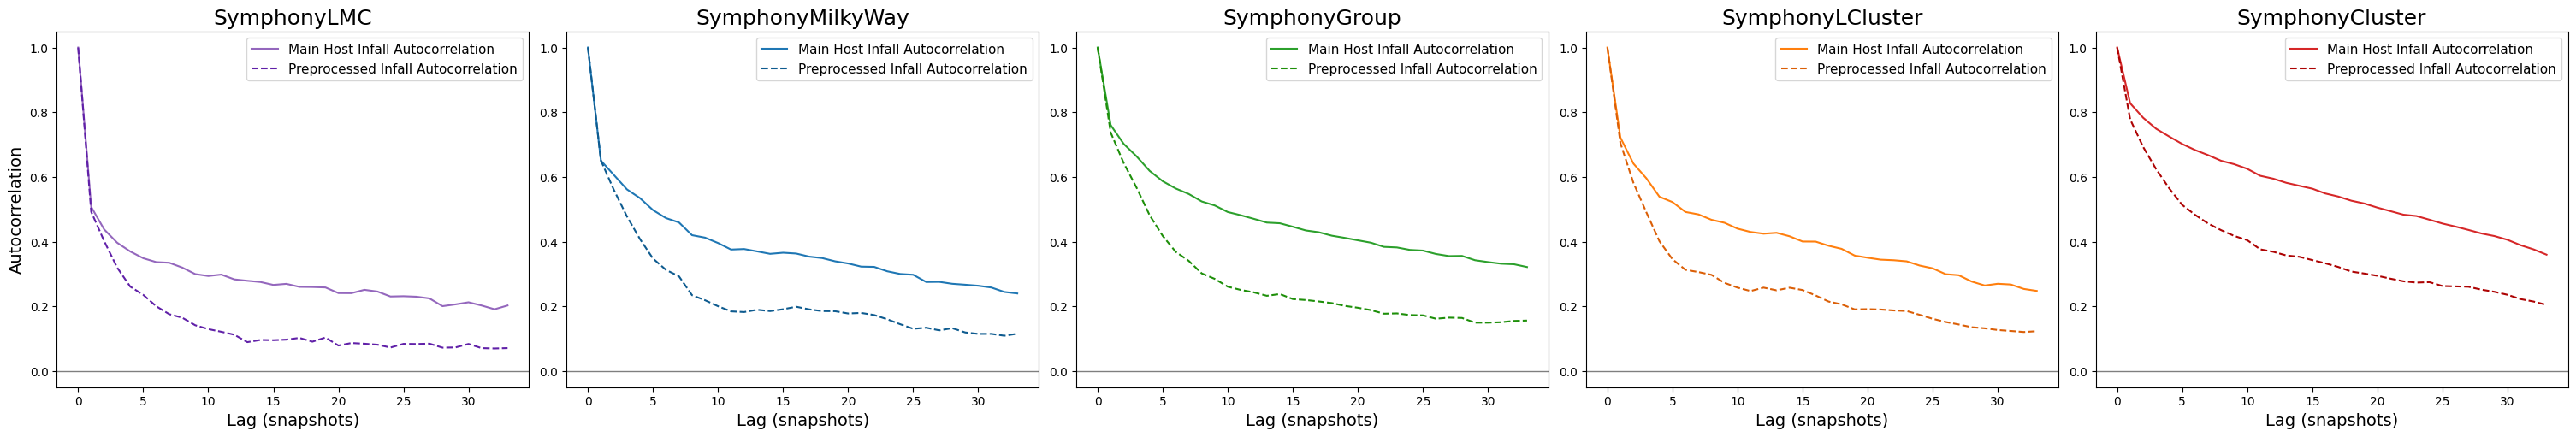

In [36]:
fig, ax = make_autocorrelation_figure(suite_data = suite_data, suite_list = suite_list, colors = colors, alt_colors = alt_colors)

#plt.savefig("Preliminary Autocorrelations")
plt.show()